# KNN classification experiment

**Research question:** How do feature scaling and the number of neighbours \(k\) affect K-nearest-neighbours classification on a two-moons dataset?

This notebook generates a synthetic 2-D classification problem, fits several KNN models, and plots decision boundaries. Run the cells **from top to bottom** so that variables are defined in the right order.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns


In [17]:
# settings
n_samples = 400
noise = 0.2
test_size = 0.3
k = 5
old_k = 3  # tried k=3 earlier
scale_x1 = 10  # stretch one feature so distances are interesting


### Generate data and scale features

In [28]:
X, y = make_moons(n_samples=n_samples, noise=noise)
# Deliberately unequal feature scales
X[:, 1] = X[:, 1] * scale_x1
# Scale features up front so KNN distances are on a comparable footing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size)
print("train", X_train.shape, "test", X_test.shape)


train (280, 2) test (120, 2)


### Quick look at the data

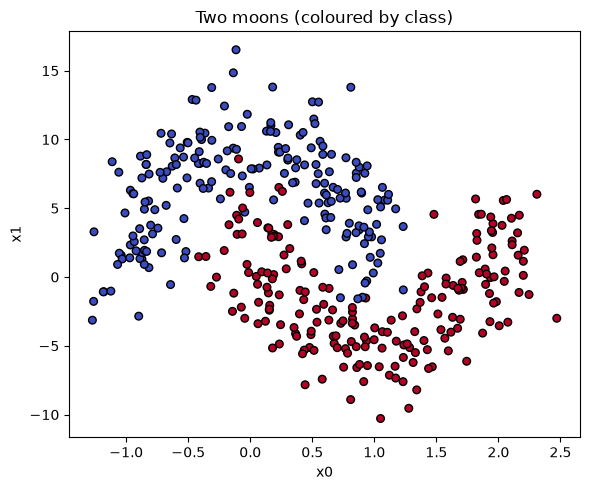

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=30)
plt.title("Two moons (coloured by class)")
plt.xlabel("x0")
plt.ylabel("x1")
plt.tight_layout()
plt.savefig("/Users/luan3potgieter/Documents/Admin/UP/STK880/reproducibility-workshop/starter_repo/outputs/dataset.png")
plt.show()


### Try a few values of k (using the test set to compare)

In [20]:
ks = [1, 3, 5, 15, 31]
accs = []
for kk in ks:
    clf = KNeighborsClassifier(n_neighbors=kk)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accs.append(acc)
    print(f"k={kk} test accuracy={acc:.3f}")

best_k = ks[int(np.argmax(accs))]
print("best k on test set:", best_k)


k=1 test accuracy=0.958
k=3 test accuracy=0.967
k=5 test accuracy=0.967
k=15 test accuracy=0.975
k=31 test accuracy=0.967
best k on test set: 15


In [37]:
# manually settle on a favourite k after looking at the plot / printout
k = 5
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)
print("accuracy with k =", k, "->", final_acc)


accuracy with k = 5 -> 0.95


### Decision boundary

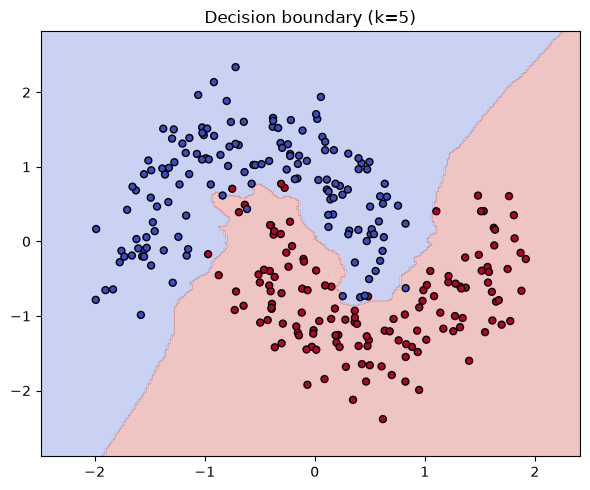

In [38]:
def plot_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=25)
    plt.title(title)
    plt.tight_layout()

plot_boundary(model, X_train, y_train, f"Decision boundary (k={k})")
plt.savefig("/Users/luan3potgieter/Documents/Admin/UP/STK880/reproducibility-workshop/starter_repo/outputs/boundary.png")
plt.show()


In [23]:
# try unscaled features too (reuse names carefully)
Xu, yu = make_moons(n_samples=n_samples, noise=noise)
Xu[:, 1] *= scale_x1
Xtr_u, Xte_u, ytr_u, yte_u = train_test_split(Xu, yu, test_size=test_size)
model_u = KNeighborsClassifier(n_neighbors=k)
model_u.fit(Xtr_u, ytr_u)
acc_u = accuracy_score(yte_u, model_u.predict(Xte_u))
print("unscaled accuracy", acc_u)

# stale leftover from an earlier pass — not used below
temp_scores = [0.91, 0.88, 0.93]


unscaled accuracy 0.9666666666666667


### Final reported accuracy

Final accuracy: 0.94
(model accuracy variable was 0.9666666666666667 )


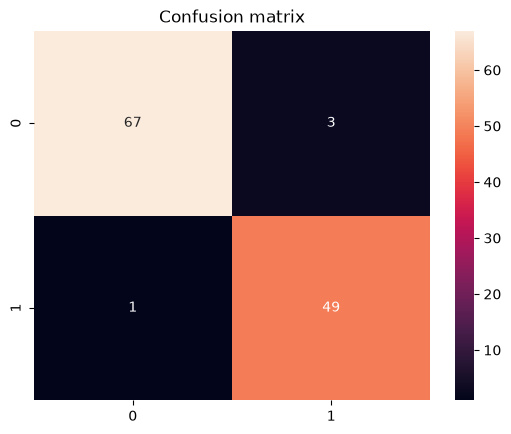

In [24]:
# hard-coded summary number used in the write-up last week
final_accuracy = 0.94
print("Final accuracy:", final_accuracy)
print("(model accuracy variable was", final_acc, ")")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.savefig("/Users/luan3potgieter/Documents/Admin/UP/STK880/reproducibility-workshop/starter_repo/outputs/confusion.png")
plt.show()


In [25]:
# save a quick results table
results = pd.DataFrame({"k": ks, "test_acc": accs})
results.to_csv("/Users/luan3potgieter/Documents/Admin/UP/STK880/reproducibility-workshop/starter_repo/outputs/results.csv", index=False)
results


,k,test_acc
0,1,0.958333
1,3,0.966667
2,5,0.966667
3,15,0.975000
4,31,0.966667
